In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
import os
print(os.getcwd())

c:\Users\Shravani\OneDrive\Desktop\Machine-Learning-Projects\Customer Churn Prediction\notebooks


In [93]:
import os
print(os.listdir())

['Customer_Churn_Prediction.ipynb']


In [94]:
df = pd.read_excel("../dataset/Telcocustomerchurn.xlsx")

In [95]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [96]:
df.shape

(7043, 33)

The dataset contains 7043 customer records and 33 columns (features).
Each row represents one customer, and each column contains information related to customer demographics, services, billing, or churn status.

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

The dataset contains a total of 33 columns.
Most of the columns have complete data with no missing values.
However, the 'Churn Reason' column contains only 1869 non-null values because the reason is available only for customers who have churned.
The dataset contains object, integer, and float data types, which will require preprocessing before training the machine learning model.

In [98]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [99]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [100]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Out of 7043 customers, 5174 customers (73.46%) did not leave the company, while 1869 customers (26.54%) churned.
This indicates that the dataset is moderately imbalanced, with a higher number of non-churn customers than churn customers.

In [101]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [102]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset.
Therefore, no duplicate rows need to be removed before building the machine learning model.

In [103]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

The dataset contains three types of data:
• Object (Categorical Data)
• Integer (Numerical Data)
• Float (Numerical Data)

Categorical columns such as Gender, Partner, Contract, and Internet Service will need to be converted into numerical values before training the machine learning model.

In [104]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


# 📊 Statistical Analysis

In this section, we analyze the statistical summary of the dataset to understand the distribution of numerical and categorical features before performing feature selection and preprocessing.

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [106]:
df = pd.read_excel("../dataset/Telcocustomerchurn.xlsx")

In [107]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [108]:
df.describe(include="all")

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
count,7043,7043.0,7043,7043,7043,7043.000000,7043,7043.000000,7043.000000,7043,...,7043,7043,7043,7043.000000,7043.0,7043,7043.000000,7043.000000,7043.000000,1869
unique,7043,NaN,1,1,1129,NaN,1652,NaN,NaN,2,...,3,2,4,NaN,6531.0,2,NaN,NaN,NaN,20
top,3668-QPYBK,NaN,United States,California,Los Angeles,NaN,"33.964131, -118.272783",NaN,NaN,Male,...,Month-to-month,Yes,Electronic check,NaN,20.2,No,NaN,NaN,NaN,Attitude of support person
freq,1,NaN,7043,7043,305,NaN,5,NaN,NaN,3555,...,3875,4171,2365,NaN,11.0,5174,NaN,NaN,NaN,192
mean,NaN,1.0,NaN,NaN,NaN,93521.964646,NaN,36.282441,-119.798880,NaN,...,NaN,NaN,NaN,64.761692,NaN,NaN,0.265370,58.699418,4400.295755,NaN
std,NaN,0.0,NaN,NaN,NaN,1865.794555,NaN,2.455723,2.157889,NaN,...,NaN,NaN,NaN,30.090047,NaN,NaN,0.441561,21.525131,1183.057152,NaN
min,NaN,1.0,NaN,NaN,NaN,90001.000000,NaN,32.555828,-124.301372,NaN,...,NaN,NaN,NaN,18.250000,NaN,NaN,0.000000,5.000000,2003.000000,NaN
25%,NaN,1.0,NaN,NaN,NaN,92102.000000,NaN,34.030915,-121.815412,NaN,...,NaN,NaN,NaN,35.500000,NaN,NaN,0.000000,40.000000,3469.000000,NaN
50%,NaN,1.0,NaN,NaN,NaN,93552.000000,NaN,36.391777,-119.730885,NaN,...,NaN,NaN,NaN,70.350000,NaN,NaN,0.000000,61.000000,4527.000000,NaN
75%,NaN,1.0,NaN,NaN,NaN,95351.000000,NaN,38.224869,-118.043237,NaN,...,NaN,NaN,NaN,89.850000,NaN,NaN,1.000000,75.000000,5380.500000,NaN


## Observation

- The dataset contains both numerical and categorical features.
- Numerical columns provide statistical measures such as mean, minimum, maximum, and standard deviation.
- Categorical columns provide information about unique values, the most frequent category, and their frequency.
- This analysis helps us understand the dataset before preprocessing and model building.

# 🎯 Feature Selection

## Objective

Feature selection is the process of selecting relevant features that contribute to predicting customer churn.

Removing irrelevant and redundant columns helps improve model performance, reduces overfitting, and decreases computational complexity.

In [109]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

### Feature Selection - CustomerID

CustomerID is a unique identifier assigned to each customer.

Since it does not contain any meaningful information related to customer churn, it will be removed before training the machine learning model.

In [110]:
df.drop("CustomerID", axis=1, inplace=True)

In [111]:
df.columns

Index(['Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude',
       'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [112]:
df["Count"].value_counts()

Count
1    7043
Name: count, dtype: int64

### Feature Selection - Count

The **Count** column contains the same value (1) for every customer.

Since it has no variation, it does not provide any useful information for predicting customer churn.

Therefore, this column was removed from the dataset.

In [113]:
df.drop("Count", axis=1, inplace=True)

In [114]:
df["Country"].value_counts()

Country
United States    7043
Name: count, dtype: int64

### Feature Selection - Country

The **Country** column contains only one unique value (**United States**) for all customers.

Since there is no variation in this feature, it does not contribute to predicting customer churn.

Therefore, this column was removed from the dataset.

In [115]:
df.drop("Country", axis=1, inplace=True)

In [116]:
location_columns = [
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
]

for col in location_columns:
    print(f"\n===== {col} =====")
    print(df[col].value_counts().head())
    print(f"Unique Values: {df[col].nunique()}")


===== State =====
State
California    7043
Name: count, dtype: int64
Unique Values: 1

===== City =====
City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
Name: count, dtype: int64
Unique Values: 1129

===== Zip Code =====
Zip Code
90003    5
91436    5
91916    5
91913    5
91911    5
Name: count, dtype: int64
Unique Values: 1652

===== Lat Long =====
Lat Long
33.964131, -118.272783    5
34.152875, -118.486056    5
32.912664, -116.635387    5
32.64164, -116.985026     5
32.607964, -117.059459    5
Name: count, dtype: int64
Unique Values: 1652

===== Latitude =====
Latitude
33.964131    5
34.152875    5
32.912664    5
32.641640    5
32.607964    5
Name: count, dtype: int64
Unique Values: 1652

===== Longitude =====
Longitude
-121.994813    8
-118.272783    5
-117.662032    5
-116.635387    5
-116.985026    5
Name: count, dtype: int64
Unique Values: 1651


### Feature Selection - State

The **State** column contains only one unique value (**California**) for all customers.

Since there is no variation in this feature, it does not provide any useful information for predicting customer churn.

Therefore, this column was removed.

In [117]:
df.drop("State", axis=1, inplace=True)

### Feature Selection - City

The **City** column contains 1129 unique values.

Although city information may provide business insights, it introduces high-cardinality categorical data, making the model more complex.

For this project, the City column was removed to simplify the model.

In [118]:
df.drop("City", axis=1, inplace=True)

### Feature Selection - Zip Code

The **Zip Code** column represents geographical locations.

Since it acts as an identifier rather than a meaningful predictive feature, it was removed from the dataset.

In [119]:
df.drop("Zip Code", axis=1, inplace=True)

### Feature Selection - Latitude and Longitude

Latitude and Longitude represent geographical coordinates.

Since geographical information is not essential for this churn prediction model and may introduce unnecessary complexity, these columns were removed.

In [120]:
df.drop(["Latitude", "Longitude"], axis=1, inplace=True)

In [121]:
df.drop("Lat Long", axis=1, inplace=True)

In [122]:
df.shape

(7043, 24)

In [123]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [124]:
df

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [125]:
df.shape

(7043, 24)

In [126]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

# ⚙️ Data Preprocessing

## Objective

The objective of this step is to prepare the dataset for machine learning by checking data types, identifying categorical features, and converting them into a numerical format suitable for model training.

In [127]:
df.dtypes

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

## Identifying Categorical Features

Before encoding, we identify all categorical columns that need to be converted into numerical values.

In [128]:
df.select_dtypes(include="object").columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges', 'Churn Label', 'Churn Reason'],
      dtype='object')

In [129]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

# 🎯 Removing Target Leakage Features

## Objective

Some columns contain information that is directly related to the target variable or is available only after customer churn.

Keeping these features during model training can lead to **data leakage**, resulting in unrealistic model performance.

Therefore, these columns are removed before building the machine learning model.

In [189]:
df.drop(
    ["Churn Value", "Churn Score", "CLTV", "Churn Reason"],
    axis=1,
    inplace=True
)

KeyError: "['Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'] not found in axis"

In [ ]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label'],
      dtype='object')

In [ ]:
df.shape

(7043, 20)

In [ ]:
df.columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label']

In [ ]:
df = pd.read_excel("../dataset/Telcocustomerchurn.xlsx")

In [ ]:
print(df.shape)
print(df.columns)

(7043, 33)
Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


In [ ]:
import os

print(os.getcwd())

c:\Users\Shravani\OneDrive\Desktop\Machine-Learning-Projects\Customer Churn Prediction\notebooks


In [ ]:
df.shape

(7043, 33)

## Step 1: Checking Data Types

### Objective

Before building a machine learning model, it is important to verify the data type of each feature.

Machine learning algorithms require numerical input. Therefore, we first identify which columns contain categorical (text) values and which contain numerical values.

In [ ]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

## Step 2: Identifying Categorical Features

### Objective

Categorical features contain text values such as **Yes/No**, **Male/Female**, or different service types.

These columns must be converted into numerical values before training the machine learning model.

In [ ]:
object_columns = df.select_dtypes(include="object").columns

print(object_columns)

Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges', 'Churn Label', 'Churn Reason'],
      dtype='object')


In [ ]:
df.select_dtypes(include="object")

,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
0,3668-QPYBK,United States,California,Los Angeles,"33.964131, -118.272783",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes,Competitor made better offer
1,9237-HQITU,United States,California,Los Angeles,"34.059281, -118.30742",Female,No,No,Yes,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes,Moved
2,9305-CDSKC,United States,California,Los Angeles,"34.048013, -118.293953",Female,No,No,Yes,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,820.5,Yes,Moved
3,7892-POOKP,United States,California,Los Angeles,"34.062125, -118.315709",Female,No,Yes,Yes,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,3046.05,Yes,Moved
4,0280-XJGEX,United States,California,Los Angeles,"34.039224, -118.266293",Male,No,No,Yes,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),5036.3,Yes,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,United States,California,Landers,"34.341737, -116.539416",Female,No,No,No,Yes,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),1419.4,No,NaN
7039,6840-RESVB,United States,California,Adelanto,"34.667815, -117.536183",Male,No,Yes,Yes,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,1990.5,No,NaN
7040,2234-XADUH,United States,California,Amboy,"34.559882, -115.637164",Female,No,Yes,Yes,Yes,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),7362.9,No,NaN
7041,4801-JZAZL,United States,California,Angelus Oaks,"34.1678, -116.86433",Female,No,Yes,Yes,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,346.45,No,NaN


In [ ]:
print(object_columns)

Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges', 'Churn Label', 'Churn Reason'],
      dtype='object')


In [ ]:
df["Total Charges"].head(10)

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
5     528.35
6      39.65
7      20.15
8    4749.15
9       30.2
Name: Total Charges, dtype: object

## Step 3: Checking Invalid Values in Total Charges

### Objective

Although the **Total Charges** column contains numeric values, its data type is **object**.

This usually happens when the column contains blank or invalid values.

We will convert this column into a numeric data type and identify any invalid entries.

In [ ]:
pd.to_numeric(df["Total Charges"], errors="coerce")

0        108.15
1        151.65
2        820.50
3       3046.05
4       5036.30
         ...   
7038    1419.40
7039    1990.50
7040    7362.90
7041     346.45
7042    6844.50
Name: Total Charges, Length: 7043, dtype: float64

In [ ]:
pd.to_numeric(df["Total Charges"], errors="coerce").isnull().sum()

np.int64(11)

## Step 4: Converting Total Charges to Numeric

The `Total Charges` column was initially stored as an object datatype because it contained 11 blank or invalid values.

Using `pd.to_numeric()` with `errors="coerce"`, invalid values are converted into `NaN`. The column can then be converted into a proper numeric datatype.

In [ ]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

## Step 5: Removing Rows with Missing Total Charges

After converting the `Total Charges` column to numeric format, the 11 invalid values became `NaN`.

Since these records represent a very small portion of the dataset, the affected rows are removed to maintain data quality.

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(1869, 33)

In [ ]:
df = pd.read_excel("../dataset/Telcocustomerchurn.xlsx")

In [ ]:
df.shape

(7043, 33)

In [ ]:
df.drop([
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason"
], axis=1, inplace=True)

In [ ]:
df.shape

(7043, 20)

In [ ]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(7032, 20)

In [ ]:
df.isnull().sum()

Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
dtype: int64

## Step 6: Encoding Categorical Features

Machine learning algorithms require numerical input and cannot directly process categorical text values.

Therefore, categorical features are converted into numerical representations using appropriate encoding techniques.

Binary categorical features containing two categories can be converted using binary encoding, while categorical features with multiple categories can be converted using one-hot encoding.

In [ ]:
for column in df.select_dtypes(include="object").columns:
    print(f"\n===== {column} =====")
    print(df[column].unique())


===== Gender =====
['Male' 'Female']

===== Senior Citizen =====
['No' 'Yes']

===== Partner =====
['No' 'Yes']

===== Dependents =====
['No' 'Yes']

===== Phone Service =====
['Yes' 'No']

===== Multiple Lines =====
['No' 'Yes' 'No phone service']

===== Internet Service =====
['DSL' 'Fiber optic' 'No']

===== Online Security =====
['Yes' 'No' 'No internet service']

===== Online Backup =====
['Yes' 'No' 'No internet service']

===== Device Protection =====
['No' 'Yes' 'No internet service']

===== Tech Support =====
['No' 'Yes' 'No internet service']

===== Streaming TV =====
['No' 'Yes' 'No internet service']

===== Streaming Movies =====
['No' 'Yes' 'No internet service']

===== Contract =====
['Month-to-month' 'Two year' 'One year']

===== Paperless Billing =====
['Yes' 'No']

===== Payment Method =====
['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

===== Churn Label =====
['Yes' 'No']


## Step 7: Categorizing Features for Encoding

Categorical features are divided into two groups based on the number of unique categories.

### Binary Features

Features with two categories can be converted into binary numerical values.

Example:

- Yes → 1
- No → 0

### Multi-Category Features

Features with more than two categories are encoded using one-hot encoding. This creates separate binary columns for each category and avoids imposing an artificial numerical order.

In [ ]:
X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]

In [ ]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [ ]:
y = y.map({"Yes": 1, "No": 0})

In [ ]:
y.value_counts()

Churn Label
0    5163
1    1869
Name: count, dtype: int64

In [ ]:
X.select_dtypes(include="object").columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
X_encoded.shape

(7032, 30)

In [ ]:
X_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,False,False,False,True,True,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,False,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,False,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,True,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
X_encoded.dtypes

Tenure Months                               int64
Monthly Charges                           float64
Total Charges                             float64
Gender_Male                                  bool
Senior Citizen_Yes                           bool
Partner_Yes                                  bool
Dependents_Yes                               bool
Phone Service_Yes                            bool
Multiple Lines_No phone service              bool
Multiple Lines_Yes                           bool
Internet Service_Fiber optic                 bool
Internet Service_No                          bool
Online Security_No internet service          bool
Online Security_Yes                          bool
Online Backup_No internet service            bool
Online Backup_Yes                            bool
Device Protection_No internet service        bool
Device Protection_Yes                        bool
Tech Support_No internet service             bool
Tech Support_Yes                             bool


In [ ]:
X_encoded.select_dtypes(include="object").columns

Index([], dtype='object')

## Step 11: Splitting the Dataset into Training and Testing Sets

The dataset is divided into training and testing subsets.

- **Training set (80%)**: Used to train the machine learning model.
- **Testing set (20%)**: Used to evaluate the model's performance on unseen data.

This helps measure how well the model generalizes to new customer data.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 30), (1407, 30), (5625,), (1407,))

## Step 12: Training the First Machine Learning Model

Logistic Regression is used as the baseline classification model for predicting customer churn.

The model learns patterns from the training data and predicts whether a customer is likely to churn or not.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [ ]:
logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Step 13: Making Predictions

After training the Logistic Regression model, predictions are generated using the unseen testing data.

The model predicts whether each customer is likely to churn or not.

In [ ]:
y_pred = logistic_model.predict(X_test)

In [ ]:
y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [ ]:
y_test[:10]

2595    0
2337    0
5032    0
975     1
5212    0
110     1
6208    0
4366    0
354     1
6053    0
Name: Churn Label, dtype: int64

## Step 14: Evaluating Model Accuracy

Accuracy measures the proportion of correct predictions made by the model out of all predictions.

It is calculated as:

Accuracy = Correct Predictions / Total Predictions

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8081023454157783


## Step 15: Classification Metrics

Accuracy alone may not be sufficient for evaluating a churn prediction model because the target classes are imbalanced.

Therefore, additional classification metrics such as Precision, Recall, F1-Score, and the Confusion Matrix are used for a more comprehensive evaluation.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.65      0.61      0.63       374

    accuracy                           0.81      1407
   macro avg       0.75      0.74      0.75      1407
weighted avg       0.80      0.81      0.81      1407



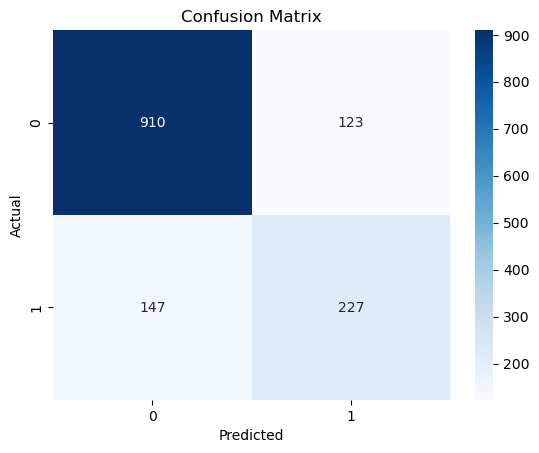

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

## Step 16: Confusion Matrix

A confusion matrix provides a detailed breakdown of the model's predictions by comparing actual values with predicted values.

It shows:

- True Negative (TN)
- False Positive (FP)
- False Negative (FN)
- True Positive (TP)

This helps identify the types of errors made by the classification model.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[910 123]
 [147 227]]


## Step 17: ROC Curve and ROC-AUC Score

Accuracy alone is not sufficient for evaluating classification models, especially when the dataset is imbalanced.

The Receiver Operating Characteristic (ROC) Curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate.

The Area Under the Curve (AUC) measures the model's ability to distinguish between customers who churn and those who do not.

A higher ROC-AUC score indicates better classification performance.

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

In [ ]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [ ]:
logistic_model.predict(X_test)

array([0, 1, 0, ..., 0, 0, 0], shape=(1407,))

In [ ]:
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.8436087715029689


## Step 18: ROC Curve

The ROC (Receiver Operating Characteristic) Curve visualizes the performance of the classification model at different threshold values.

The closer the ROC curve is to the top-left corner, the better the model can distinguish between customers who churn and those who do not.

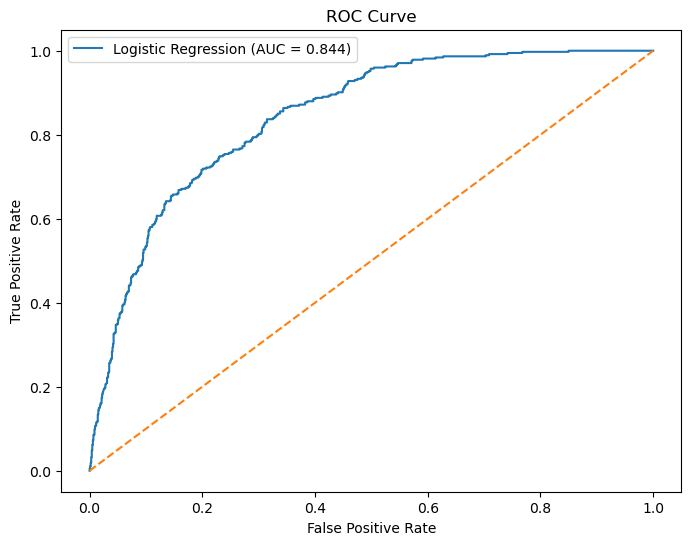

In [190]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# Step 19: Decision Tree Classifier

## Objective

Decision Tree is a supervised machine learning algorithm used for classification problems.

Unlike Logistic Regression, Decision Tree learns by creating a tree-like structure of decision rules based on the input features.

In this project, we train a Decision Tree model and compare its performance with Logistic Regression.

In [197]:
from sklearn.tree import DecisionTreeClassifier

In [198]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [199]:
dt_model = DecisionTreeClassifier()

In [200]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [201]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Step 20: Making Predictions using Decision Tree

After training the Decision Tree model, predictions are generated using the testing dataset.

The trained model predicts whether each customer will churn or not.

In [202]:
y_pred_dt = dt_model.predict(X_test)

In [203]:
y_pred_dt[:10]

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 0])

In [204]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.720682302771855


In [206]:
# Decision Tree predictions
dt_pred = dt_model.predict(X_test)

In [207]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, dt_pred)

print(cm)

[[828 205]
 [188 186]]


In [208]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1033
           1       0.48      0.50      0.49       374

    accuracy                           0.72      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.72      0.72      0.72      1407



In [209]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1033
           1       0.48      0.50      0.49       374

    accuracy                           0.72      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.72      0.72      0.72      1407



In [210]:
dt_model_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model_tuned.fit(X_train, y_train)

dt_pred_tuned = dt_model_tuned.predict(X_test)

In [211]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, dt_pred_tuned))

print(classification_report(y_test, dt_pred_tuned))

Accuracy: 0.7818052594171997
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.58      0.63      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.73      1407
weighted avg       0.79      0.78      0.78      1407



In [212]:
from sklearn.tree import DecisionTreeClassifier

dt_model_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model_tuned.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [213]:
dt_pred_tuned = dt_model_tuned.predict(X_test)

In [214]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, dt_pred_tuned))

print(classification_report(y_test, dt_pred_tuned))

Accuracy: 0.7818052594171997
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.58      0.63      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.73      1407
weighted avg       0.79      0.78      0.78      1407



In [215]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, dt_pred_tuned)

print(cm)

[[865 168]
 [139 235]]


In [216]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [217]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7924662402274343
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407



In [218]:
from sklearn.metrics import roc_auc_score

rf_prob = rf_model.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", auc_score)

Random Forest ROC-AUC: 0.8285133379233942


In [219]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,Total Charges,0.192243
0,Tenure Months,0.167755
1,Monthly Charges,0.163149
6,Dependents_Yes,0.039969
10,Internet Service_Fiber optic,0.039381
28,Payment Method_Electronic check,0.036354
25,Contract_Two year,0.029610
3,Gender_Male,0.027725
13,Online Security_Yes,0.026148
26,Paperless Billing_Yes,0.024855


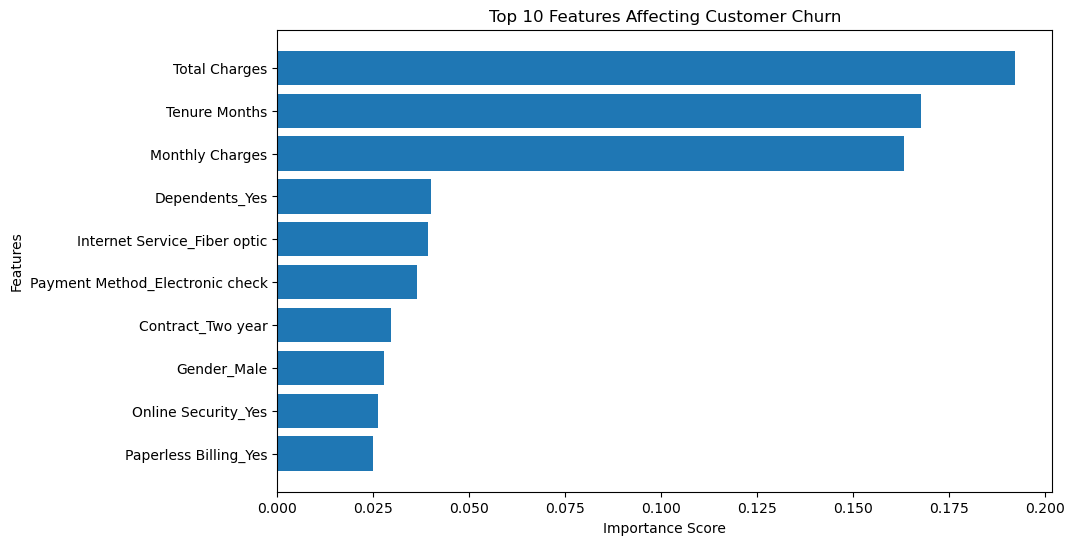

In [220]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Features Affecting Customer Churn")

plt.gca().invert_yaxis()

plt.show()

In [221]:
import joblib

joblib.dump(rf_model, "customer_churn_random_forest.pkl")

['customer_churn_random_forest.pkl']

In [222]:
import os

os.listdir()

['Customer_Churn_Prediction.ipynb', 'customer_churn_random_forest.pkl']

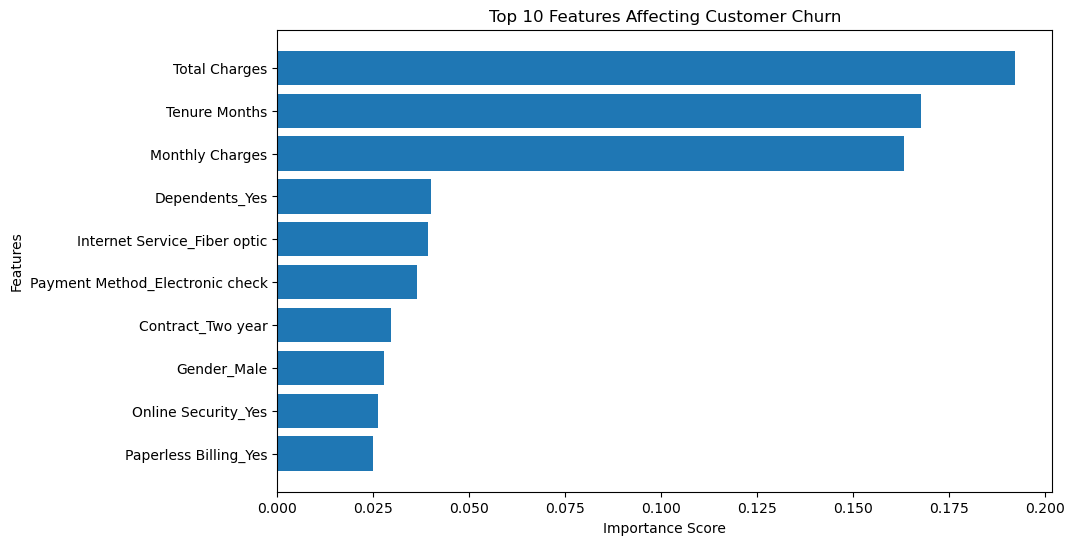

In [223]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Features Affecting Customer Churn")

plt.gca().invert_yaxis()

plt.show()